In [1]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/adityajn105/flickr8k


In [2]:
import os

os.listdir(path)

['captions.txt', 'Images']

**Configuration des chemins et Nettoyage**

In [4]:
import os
import re
import pandas as pd

# Utilisation du chemin fourni par kagglehub
images_dir = os.path.join(path, "Images")
captions_file = os.path.join(path, "captions.txt")

# Chargement des données
df = pd.read_csv(captions_file)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    text = f"startseq {text} endseq"
    return text

# Nettoyage
df['caption'] = df['caption'].apply(clean_text)

# Création du mapping {image: [cap1, cap2, cap3, cap4, cap5]}
mapping = {}
for i, row in df.iterrows():
    img_name = row['image']
    caption = row['caption']
    if img_name not in mapping:
        mapping[img_name] = []
    mapping[img_name].append(caption)

print(f"Nombre d'images chargées : {len(mapping)}")

Nombre d'images chargées : 8091


**Extraction des Features avec ResNet50**

In [5]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
import pickle
from tqdm import tqdm

# On charge ResNet50 sans la dernière couche de classification
base_model = ResNet50(weights='imagenet')
model_cnn = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

features = {}

# Extraction
for img_name in tqdm(mapping.keys()):
    img_path = os.path.join(images_dir, img_name)
    
    # Prétraitement de l'image
    image = load_img(img_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    
    # Extraction du vecteur de 2048 caractéristiques
    feature = model_cnn.predict(image, verbose=0)
    features[img_name] = feature

# Sauvegarde sur le disque de Kaggle
with open('/kaggle/working/features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("\nExtraction terminée et fichier 'features.pkl' enregistré !")

2026-05-07 23:57:17.716904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778198238.152605      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778198238.269845      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778198239.279553      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778198239.279606      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778198239.279610      57 computation_placer.cc:177] computation placer alr

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


  0%|          | 0/8091 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1778198279.038436     132 service.cc:152] XLA service 0x78b4fc0087a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778198279.038485     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778198279.038489     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778198279.941282     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778198283.438613     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 8091/8091 [15:26<00:00,  8.73it/s]



Extraction terminée et fichier 'features.pkl' enregistré !


**Tokenisation (Préparation du texte)**

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

# On regroupe toutes les phrases pour construire le vocabulaire
all_captions = [cap for caps in mapping.values() for cap in caps]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

# On calcule la longueur maximale d'une phrase pour le padding
max_length = max(len(cap.split()) for cap in all_captions)

print(f"Taille du vocabulaire : {vocab_size}")
print(f"Longueur max d'une légende : {max_length}")

Taille du vocabulaire : 8444
Longueur max d'une légende : 38


**Le Data Generator**

In [7]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    while True:
        X1, X2, y = list(), list(), list()
        n = 0
        for key in data_keys:
            n += 1
            captions = mapping[key]
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    
                    # CORRECTION : On ajoute padding='post' pour mettre les zéros à la fin
                    # C'est ce que cuDNN exige pour fonctionner à pleine vitesse
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            
            if n == batch_size:
                yield ( (np.array(X1), np.array(X2)), np.array(y) )
                X1, X2, y = list(), list(), list()
                n = 0

**Architecture du Modèle (CNN + RNN)**

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model

# --- 1. DEFINITION DU MODELE DE CAPTIONING ---
# On utilise le nom 'caption_model' pour correspondre à ton script d'entraînement

# Branche Image
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Branche Texte
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# Fusion
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# ON DECOUPLE LE NOM : caption_model
caption_model = Model(inputs=[inputs1, inputs2], outputs=outputs)

# Compilation
caption_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

print("Modèle de captioning créé et compilé sous le nom 'caption_model'")


Modèle de captioning créé et compilé sous le nom 'caption_model'


In [9]:
#Extraction des features avec CNN
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# base_model = ResNet50(weights='imagenet')

# model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
base_model = ResNet50(weights='imagenet')
# On appelle ça 'fe_model' (feature extractor model) pour ne pas tout casser
fe_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

print("Modèle ResNet prêt sous le nom 'fe_model'")

Modèle ResNet prêt sous le nom 'fe_model'


**Division Train/Test et Entraînement**

In [10]:
import random

# Division Train / Test (90% / 10%)
all_images = list(mapping.keys())
random.shuffle(all_images)

split = int(len(all_images) * 0.90)
train = all_images[:split]
test  = all_images[split:]

print(f"Images pour l'entraînement : {len(train)}")
print(f"Images pour le test        : {len(test)}")

Images pour l'entraînement : 7281
Images pour le test        : 810


In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf

# On s'assure que le modèle est bien prêt
# (On garde le nom 'caption_model' pour éviter les conflits)

# Paramètres
batch_size = 64
epochs = 20

# Recréation du Dataset avec le nouveau générateur
train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size),
    output_signature=(
        (
            tf.TensorSpec(shape=(None, 2048), dtype=tf.float32), 
            tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)
        ),
        tf.TensorSpec(shape=(None,), dtype=tf.int32)
    )
).prefetch(buffer_size=tf.data.AUTOTUNE)

# Callback pour sauvegarder le meilleur modèle
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_model.keras',
    monitor='loss',
    save_best_only=True,
    verbose=1
)

print("Lancement de l'entraînement avec Post-Padding (cuDNN compatible)...")
caption_model.fit(
    train_ds,
    epochs=epochs,
    steps_per_epoch=len(train) // batch_size,
    callbacks=[checkpoint],
    verbose=1
)

Lancement de l'entraînement avec Post-Padding (cuDNN compatible)...
Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 5.8834
Epoch 1: loss improved from inf to 5.10309, saving model to /kaggle/working/best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - loss: 5.8766
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 3.9239
Epoch 2: loss improved from 5.10309 to 3.74316, saving model to /kaggle/working/best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 3.9224
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 3.3678
Epoch 3: loss improved from 3.74316 to 3.29476, saving model to /kaggle/working/best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 3.3672
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 3.1027
Epoch 4: loss improved from 3.29476 to 3.05783, saving model to /kaggle/working/best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 3.1023
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 9

Génération des prédictions sur le set de test (100 images)...


100%|██████████| 100/100 [01:59<00:00,  1.19s/it]



MÉTRIQUES D'ÉVALUATION DU MODÈLE

SCORES BLEU (Image Captioning)
   BLEU-1 : 0.5627  (56.27%)
   BLEU-2 : 0.3723  (37.23%)
   BLEU-3 : 0.2369  (23.69%)
   BLEU-4 : 0.1481  (14.81%)

MÉTRIQUES TOKEN-LEVEL (sur 1085 tokens)
   Accuracy  : 0.2369  (23.69%)
   Precision : 0.2013  (20.13%)
   Recall    : 0.2369  (23.69%)
   F1-Score  : 0.2136  (21.36%)

LONGUEUR MOYENNE
   Légendes prédites : 11.4 mots
   Légendes réelles  : 13.5 mots


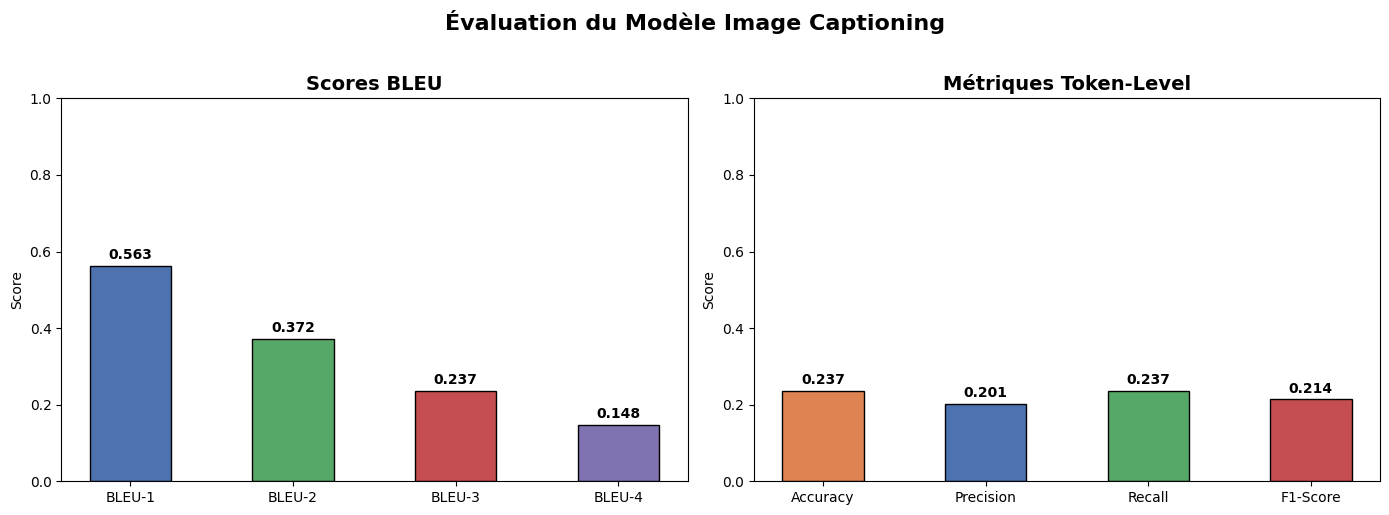

Graphique sauvegardé : evaluation_metrics.png


In [12]:
# ============================================================
# ÉVALUATION COMPLÈTE DU MODÈLE
# ============================================================
import numpy as np
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 1. GÉNÉRATION DES PRÉDICTIONS SUR LE SET DE TEST
# -----------------------------------------------------------
actual, predicted = [], []
all_y_true, all_y_pred = [], []  # pour accuracy token-level

print("Génération des prédictions sur le set de test (100 images)...")

for key in tqdm(test[:100]):
    feature = features[key]
    references = [d.split() for d in mapping[key]]

    # Prédiction greedy (mot par mot)
    in_text = 'startseq'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = caption_model.predict([feature, sequence], verbose=0)
        yhat_idx = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat_idx, None)
        if word is None or word == 'endseq':
            break
        in_text += ' ' + word

    candidate = in_text.replace('startseq', '').strip().split()
    actual.append(references)
    predicted.append(candidate)

    # Token-level accuracy : comparer seq prédite vs 1ère référence
    ref_seq = tokenizer.texts_to_sequences([mapping[key][0]])[0]
    pred_seq = tokenizer.texts_to_sequences([in_text])[0]
    min_len = min(len(ref_seq), len(pred_seq))
    all_y_true.extend(ref_seq[:min_len])
    all_y_pred.extend(pred_seq[:min_len])

# -----------------------------------------------------------
# 2. SCORES BLEU (métrique principale en captioning)
# -----------------------------------------------------------
bleu1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))
bleu2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0))
bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))

# -----------------------------------------------------------
# 3. TOKEN-LEVEL ACCURACY, PRECISION, RECALL, F1
# -----------------------------------------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

token_accuracy  = accuracy_score(all_y_true, all_y_pred)
token_precision = precision_score(all_y_true, all_y_pred, average='weighted', zero_division=0)
token_recall    = recall_score(all_y_true, all_y_pred, average='weighted', zero_division=0)
token_f1        = f1_score(all_y_true, all_y_pred, average='weighted', zero_division=0)

# -----------------------------------------------------------
# 4. LONGUEUR MOYENNE DES LÉGENDES
# -----------------------------------------------------------
avg_pred_len = np.mean([len(p) for p in predicted])
avg_ref_len  = np.mean([len(r[0]) for r in actual])

# -----------------------------------------------------------
# 5. AFFICHAGE COMPLET
# -----------------------------------------------------------
print("\n" + "="*55)
print("MÉTRIQUES D'ÉVALUATION DU MODÈLE")
print("="*55)
print(f"\nSCORES BLEU (Image Captioning)")
print(f"   BLEU-1 : {bleu1:.4f}  ({bleu1*100:.2f}%)")
print(f"   BLEU-2 : {bleu2:.4f}  ({bleu2*100:.2f}%)")
print(f"   BLEU-3 : {bleu3:.4f}  ({bleu3*100:.2f}%)")
print(f"   BLEU-4 : {bleu4:.4f}  ({bleu4*100:.2f}%)")

print(f"\nMÉTRIQUES TOKEN-LEVEL (sur {len(all_y_true)} tokens)")
print(f"   Accuracy  : {token_accuracy:.4f}  ({token_accuracy*100:.2f}%)")
print(f"   Precision : {token_precision:.4f}  ({token_precision*100:.2f}%)")
print(f"   Recall    : {token_recall:.4f}  ({token_recall*100:.2f}%)")
print(f"   F1-Score  : {token_f1:.4f}  ({token_f1*100:.2f}%)")

print(f"\nLONGUEUR MOYENNE")
print(f"   Légendes prédites : {avg_pred_len:.1f} mots")
print(f"   Légendes réelles  : {avg_ref_len:.1f} mots")
print("="*55)

# -----------------------------------------------------------
# 6. GRAPHIQUE VISUEL
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Scores BLEU
bleu_labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
bleu_scores = [bleu1, bleu2, bleu3, bleu4]
colors_bleu = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = axes[0].bar(bleu_labels, bleu_scores, color=colors_bleu, edgecolor='black', width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('Scores BLEU', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
for bar, score in zip(bars, bleu_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Graphique 2 : Token-level metrics
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_scores = [token_accuracy, token_precision, token_recall, token_f1]
colors_tok = ['#DD8452', '#4C72B0', '#55A868', '#C44E52']
bars2 = axes[1].bar(metric_labels, metric_scores, color=colors_tok, edgecolor='black', width=0.5)
axes[1].set_ylim(0, 1)
axes[1].set_title('Métriques Token-Level', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
for bar, score in zip(bars2, metric_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Évaluation du Modèle Image Captioning', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : evaluation_metrics.png")

**Fonction de génération de légende (Inférence)**

On crée une fonction qui prend une image et génère une phrase mot par mot.

In [13]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def beam_search_predictions(model, image_feature, tokenizer, max_length, beam_index=3):
    start = [tokenizer.word_index['startseq']]
    # [ [liste_mots, probabilité_cumulée] ]
    start_word = [[start, 0.0]]
    
    while len(start_word[0][0]) < max_length:
        temp = []
        for s in start_word:
            par_caps = pad_sequences([s[0]], maxlen=max_length, padding='post')
            preds = model.predict([image_feature, par_caps], verbose=0)
            
            # On prend les 'beam_index' meilleurs mots suivants
            word_preds = np.argsort(preds[0])[-beam_index:]
            
            for w in word_preds:
                next_cap, prob = s[0][:], s[1]
                next_cap.append(w)
                prob += np.log(preds[0][w] + 1e-10) # Log pour éviter les nombres minuscules
                temp.append([next_cap, prob])
        
        start_word = temp
        # Trier par probabilité et garder les 'beam_index' meilleurs
        start_word = sorted(start_word, reverse=False, key=lambda l: l[1])
        start_word = start_word[-beam_index:]
    
    # Prendre la meilleure séquence
    final_idx = start_word[-1][0]
    final_caption = []
    for i in final_idx:
        word = idx_to_word(i, tokenizer)
        if word == 'endseq':
            break
        final_caption.append(word)
        
    return ' '.join(final_caption[1:]) # On enlève startseq

# Teste avec Beam Search sur la même image
# display_prediction_beam(test[5])

**Évaluation avec le Score BLEU**

In [14]:
# from nltk.translate.bleu_score import corpus_bleu
# from tqdm import tqdm

# actual, predicted = list(), list()

# # On teste sur un échantillon du set de test pour aller vite (ex: 100 images)
# for key in tqdm(test[:100]):
#     # Légendes réelles
#     references = [d.split() for d in mapping[key]]
#     # Légende prédite
#     feature = features[key]
#     y_pred = beam_search_predictions(caption_model, feature, tokenizer, max_length)
#     candidate = y_pred.split()
    
#     actual.append(references)
#     predicted.append(candidate)

# # Calcul des scores BLEU
# print(f"BLEU-1: {corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))}")
# print(f"BLEU-2: {corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))}")

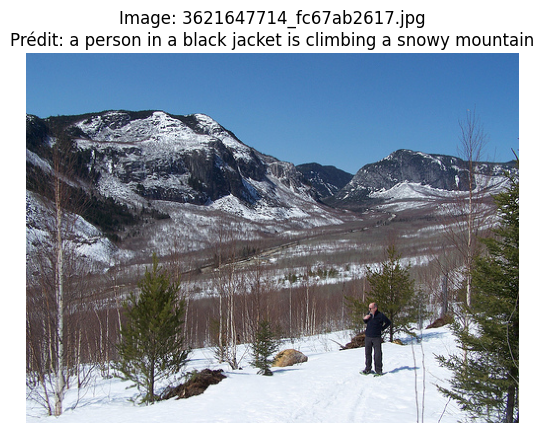

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def display_prediction(img_name):
    # 1. Charger l'image
    img_path = os.path.join(images_dir, img_name)
    image = Image.open(img_path)
    
    # 2. Récupérer les caractéristiques (features)
    feature = features[img_name]
    
    # 3. UTILISER LE NOM QUI FONCTIONNE DÉJÀ CHEZ TOI : beam_search_predictions
    caption = beam_search_predictions(caption_model, feature, tokenizer, max_length)
    
    # 4. Nettoyer la légende
    clean_cap = caption.replace('startseq', '').replace('endseq', '').strip()
    
    # Affichage
    plt.imshow(image)
    plt.title(f"Image: {img_name}\nPrédit: {clean_cap}")
    plt.axis('off')
    plt.show()

# Tester
display_prediction(test[7])

In [16]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_caption(model, image_feature, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = model.predict([image_feature, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = None
        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break
        if word is None:
            break
        in_text += " " + word
        if word == 'endseq':
            break
    return in_text

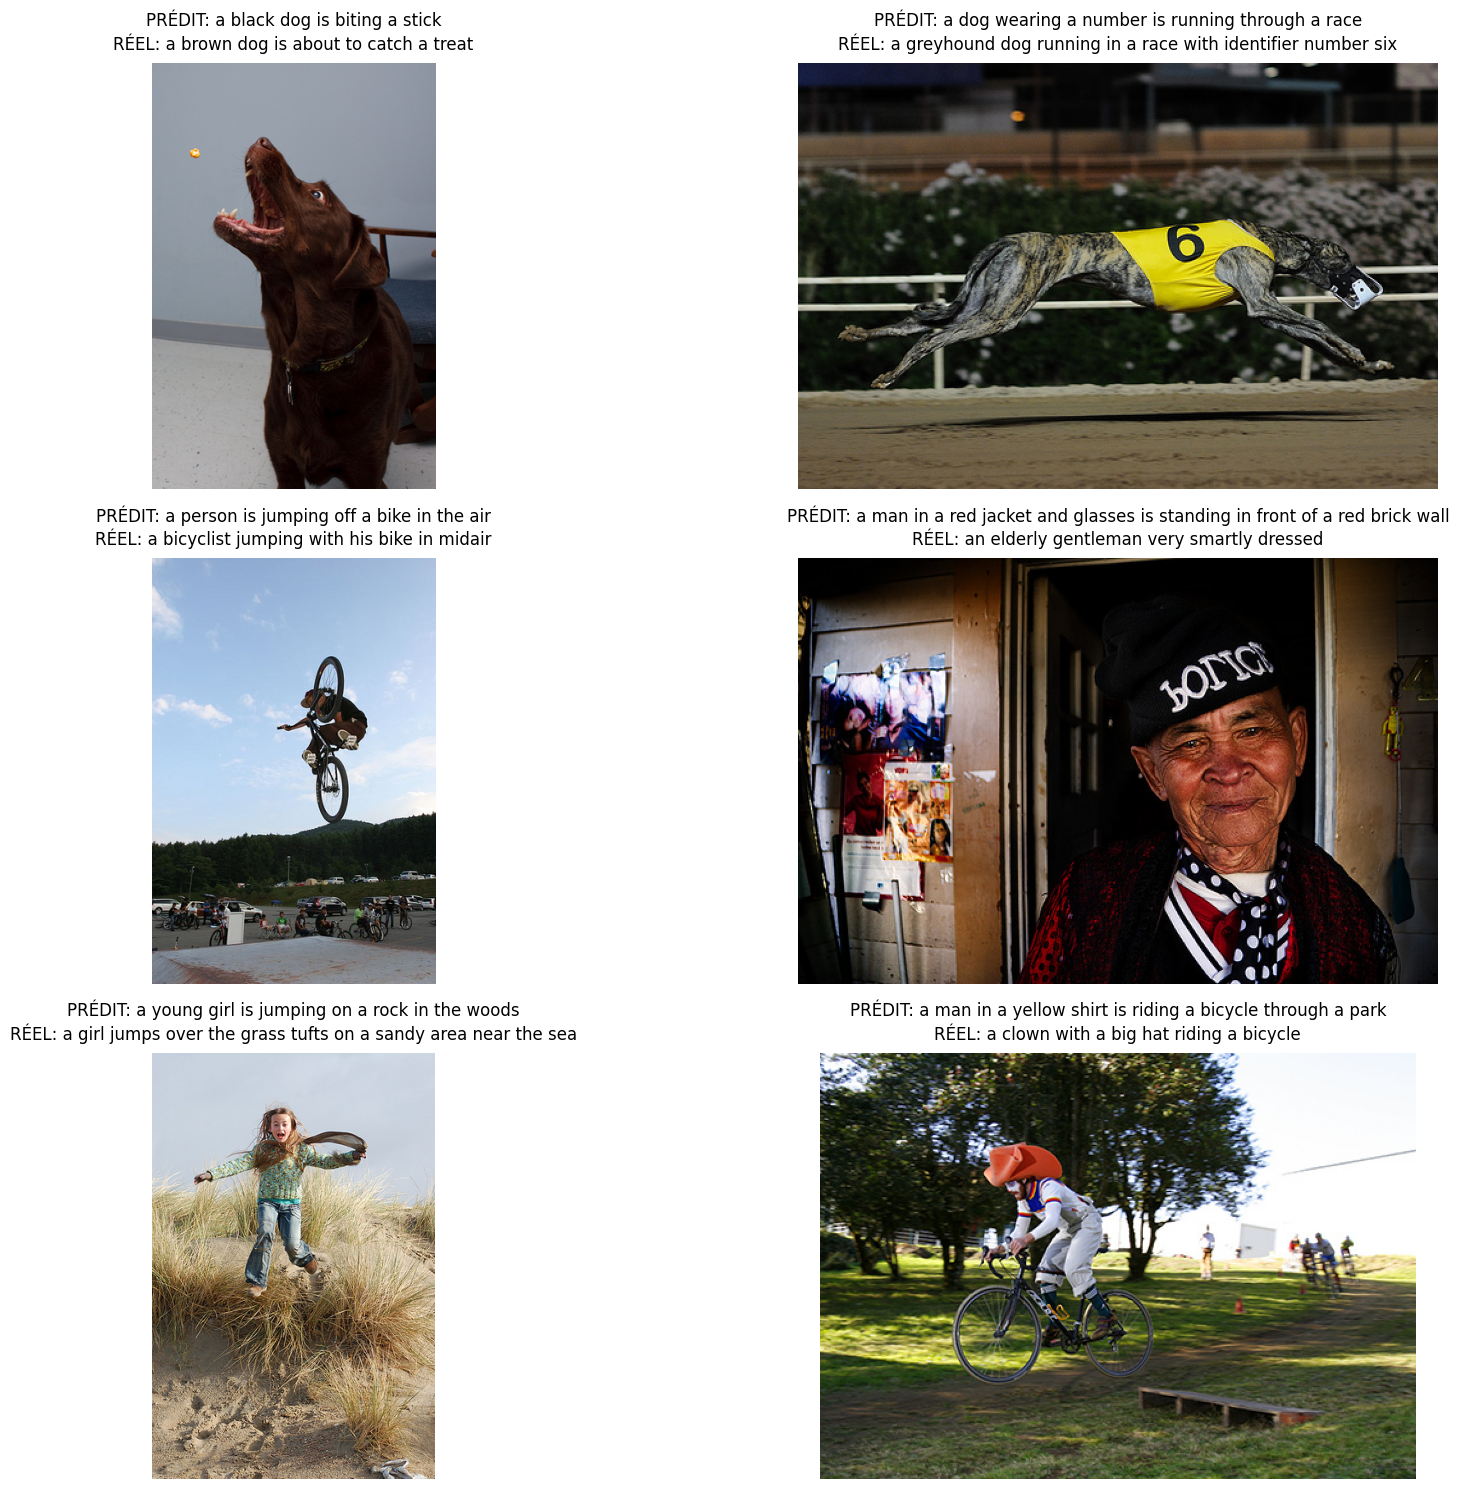

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_multiple_results(test_list, num_images=6):
    plt.figure(figsize=(20, 15))
    
    # Choisir des images au hasard dans le set de test
    random_images = random.sample(test_list, num_images)
    
    for i, img_name in enumerate(random_images):
        # 1. Charger l'image
        img_path = os.path.join(images_dir, img_name)
        image = Image.open(img_path)
        
        # 2. Prédire la légende
        feature = features[img_name]
        predicted_cap = predict_caption(caption_model, feature, tokenizer, max_length)
        
        # Nettoyage pour l'affichage
        predicted_cap = predicted_cap.replace('startseq', '').replace('endseq', '').strip()
        
        # 3. Récupérer une légende réelle (la première du mapping)
        actual_cap = mapping[img_name][0]
        actual_cap = actual_cap.replace('startseq', '').replace('endseq', '').strip()
        
        # 4. Affichage
        plt.subplot(3, 2, i+1)
        plt.imshow(image)
        # On affiche en vert si le modèle semble cohérent, en rouge s'il est loin
        plt.title(f"PRÉDIT: {predicted_cap}\nRÉEL: {actual_cap}", fontsize=12, pad=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Lancer la visualisation
show_multiple_results(test, num_images=6)

In [18]:
import pickle

# 1. Sauvegarder le Tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)


print("Fichiers prêts pour le déploiement !")

Fichiers prêts pour le déploiement !


In [19]:
pip install streamlit tensorflow pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 107.1 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.


In [20]:
import streamlit as st
import tensorflow as tf
import numpy as np
import pickle
from PIL import Image
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- CONFIGURATION DE LA PAGE ---
st.set_page_config(page_title="Image Captioning AI", layout="centered")
st.title("📸 Générateur Automatique de Légendes")
st.markdown("Déposé une image et l'IA va décrire son contenu.")

# --- CHARGEMENT DES MODÈLES (Caching pour plus de vitesse) ---
@st.cache_resource
def load_ai_models():
    # 1. Modèle CNN pour l'extraction (ResNet50)
    base_model = ResNet50(weights='imagenet')
    cnn_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
    
    # 2. Ton modèle entraîné (ajuste le nom du fichier)
    caption_model = load_model('best_model.keras')
    
    # 3. Le Tokenizer
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
        
    return cnn_model, caption_model, tokenizer

cnn_model, caption_model, tokenizer = load_ai_models()
max_length = 38 # La même que pendant l'entraînement

# --- FONCTIONS UTILITAIRES ---
def predict_caption(model, image_feature, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = model.predict([image_feature, sequence], verbose=0)
        yhat = np.argmax(yhat)
        
        word = None
        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break
        
        if word is None or word == 'endseq':
            break
        in_text += " " + word
    return in_text.replace('startseq', '').strip()

# --- INTERFACE UTILISATEUR ---
uploaded_file = st.file_uploader("Choisissez une image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Affichage de l'image
    image = Image.open(uploaded_file)
    st.image(image, caption='Image téléchargée', use_column_width=True)
    
    with st.spinner('L\'IA analyse l\'image...'):
        # 1. Prétraitement
        img = image.resize((224, 224))
        img = img_to_array(img)
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)
        
        # 2. Extraction des features
        feature = cnn_model.predict(img, verbose=0)
        
        # 3. Génération de la légende
        caption = predict_caption(caption_model, feature, tokenizer, max_length)
        
        # 4. Résultat
        st.success(f"**Légende prédite :** {caption}")

2026-05-08 00:36:13.034 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 00:36:13.035 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 00:36:13.517 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-08 00:36:13.518 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 00:36:13.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 00:36:13.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 00:36:13.520 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
#!pip install gradio -q

In [26]:
import gradio as gr
import tensorflow as tf
import numpy as np
import pickle
from PIL import Image
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Chargement des modèles
base_model = ResNet50(weights='imagenet')
cnn_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
caption_model = load_model('best_model.keras')

with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

max_length = 38

# 2. Fonction de prédiction
def generate_caption(input_image):
    if input_image is None:
        return "Veuillez charger une image."
    
    # Prétraitement de l'image
    img = input_image.resize((224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    
    # Extraction des features
    feature = cnn_model.predict(img, verbose=0)
    
    # Génération de la légende
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = caption_model.predict([feature, sequence], verbose=0)
        yhat = np.argmax(yhat)
        
        word = None
        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break
        
        if word is None or word == 'endseq':
            break
        in_text += " " + word
    
    result = in_text.replace('startseq', '').strip()
    return result

# 3. Création de l'interface Gradio (Design Pro)
demo = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="pil", label="Uploader une Image"),
    outputs=gr.Textbox(label="Légende générée par l'IA"),
    title="📸 AI Image Captioning System",
    description="Ce système utilise un réseau de neurones CNN (ResNet50) et un RNN (LSTM) pour générer une description textuelle d'une image.",
    examples=["Images/1000268201_693b08cb0e.jpg"], # Optionnel : si tu as des exemples
    theme=gr.themes.Soft()
)

# 4. Lancement (share=True crée le lien public automatiquement)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a70dded4a2857fe1f1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pickle

# 1. Sauvegarder le modèle de Captioning (le plus important)
caption_model.save('caption_model_final.keras')

# 2. Sauvegarder le modèle d'extraction (ResNet) pour traiter les futures images
fe_model.save('feature_extractor.keras')

# 3. Sauvegarder le Tokenizer avec pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 4. Sauvegarder la configuration importante (max_length)
# Tu en auras besoin pour le padding lors du déploiement
config = {'max_length': max_length}
with open('config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("Tous les fichiers ont été sauvegardés avec succès !")